# Day 3 Exploratory Data Analysis (EDA)

This notebook contains the Day 3 EDA deliverable with 15+ charts, Plotly visualizations, and exported PNG outputs.

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # type: ignore
from matplotlib.patches import Rectangle, Circle
from pathlib import Path

sns.set(style='whitegrid', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

BASE_DIR = Path('..')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fund_master = pd.read_csv(BASE_DIR / 'data' / 'processed' / '01_fund_master.csv', parse_dates=['launch_date'])
nav_history = pd.read_csv(BASE_DIR / 'data' / 'processed' / '02_nav_history.csv', parse_dates=['date'])
aum_by_house = pd.read_csv(BASE_DIR / 'data' / 'processed' / '03_aum_by_fund_house.csv', parse_dates=['date'])
sip_inflows = pd.read_csv(BASE_DIR / 'data' / 'processed' / '04_monthly_sip_inflows.csv', parse_dates=['month'])
category_inflows = pd.read_csv(BASE_DIR / 'data' / 'processed' / '05_category_inflows.csv', parse_dates=['month'])
folio_count = pd.read_csv(BASE_DIR / 'data' / 'processed' / '06_industry_folio_count.csv', parse_dates=['month'])
scheme_perf = pd.read_csv(BASE_DIR / 'data' / 'processed' / '07_scheme_performance.csv')
transactions = pd.read_csv(BASE_DIR / 'data' / 'processed' / '08_investor_transactions.csv', parse_dates=['transaction_date'])
portfolio_holdings = pd.read_csv(BASE_DIR / 'data' / 'processed' / '09_portfolio_holdings.csv', parse_dates=['portfolio_date'])
benchmark = pd.read_csv(BASE_DIR / 'data' / 'processed' / '10_benchmark_indices.csv', parse_dates=['date'])

fund_master.head()

## 1. NAV Trend Analysis — Plotly

Daily NAV for all 40 schemes from 2022 to 2026, with 2023 bull run and 2024 market corrections highlighted.

In [2]:
fig = px.line(
    nav_history.sort_values(['amfi_code', 'date']),
    x='date', y='nav', color='amfi_code',
    title='Daily NAV Trend for 40 Mutual Fund Schemes (2022-2026)',
    labels={'nav': 'NAV', 'date': 'Date', 'amfi_code': 'AMFI Code'}
)
fig.update_layout(showlegend=False)
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='rgba(0,200,0,0.06)', line_width=0, layer='below', annotation_text='2023 bull run', annotation_position='top left')
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='rgba(200,0,0,0.06)', line_width=0, layer='below', annotation_text='2024 correction phase', annotation_position='top right')
fig.write_html(PLOTS_DIR / 'nav_trends.html')
fig.write_image(PLOTS_DIR / 'nav_trends.png')
fig

## 2. AUM Growth by Fund House — Seaborn

Grouped bar chart showing annual AUM growth for each fund house from 2022 to 2025, with SBI dominance highlighted.

C:\Users\rajve\AppData\Local\Temp\ipykernel_30624\3983178929.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


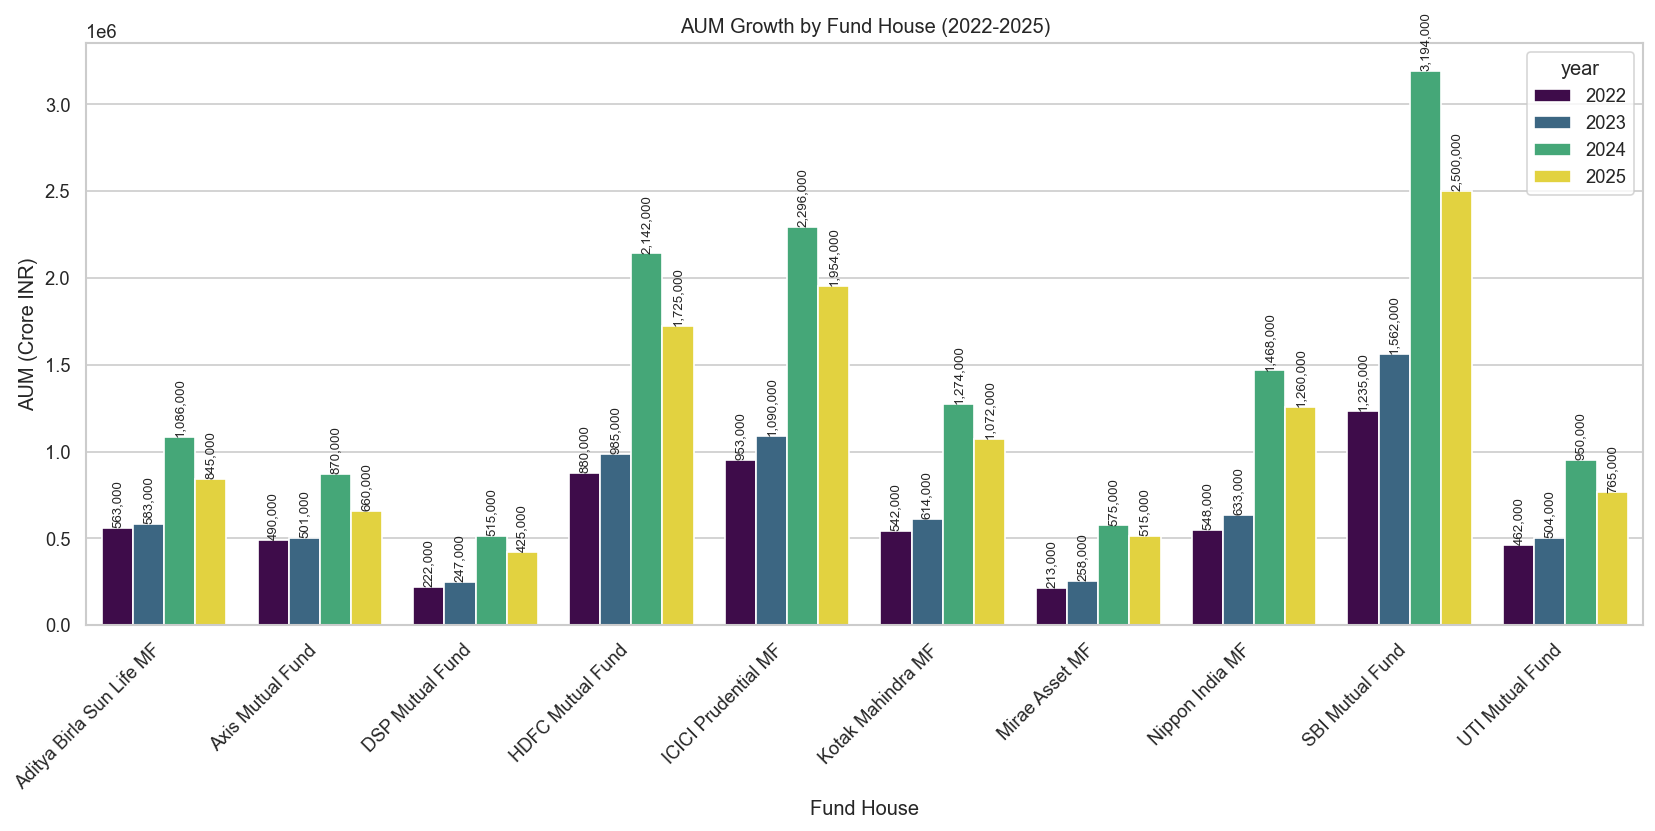

In [3]:
fund_house_year = (
    aum_by_house.assign(year=aum_by_house['date'].dt.year)
    .query('year >= 2022 and year <= 2025')
    .groupby(['fund_house', 'year'], as_index=False)
    .agg(aum_crore=('aum_crore', 'sum'))
)
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=fund_house_year, x='fund_house', y='aum_crore', hue='year', palette='viridis')
ax.set_title('AUM Growth by Fund House (2022-2025)')
ax.set_xlabel('Fund House')
ax.set_ylabel('AUM (Crore INR)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for p in ax.patches:
    if not isinstance(p, Rectangle):
        continue
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height):,}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90,
        )
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'aum_growth_by_house.png')
plt.show()

## 3. SIP Inflow Time-Series — Plotly

Monthly SIP trend from Jan 2022 to Dec 2025, with the ₹31,002 Cr all-time high annotated.

In [4]:
sip_sort = sip_inflows.query('month >= "2022-01-01" and month <= "2025-12-31"').sort_values('month')
fig = px.line(sip_sort, x='month', y='sip_inflow_crore', title='Monthly SIP Inflows (Jan 2022 - Dec 2025)', markers=True)
max_row = sip_sort.loc[sip_sort['sip_inflow_crore'].idxmax()]
max_month = pd.Timestamp(max_row['month']).isoformat() # type: ignore
max_value = float(max_row['sip_inflow_crore']) # pyright: ignore[reportArgumentType]
fig.add_annotation(x=max_month, y=max_value, text=f'₹{int(max_value):,} Cr peak (Dec 2025)', showarrow=True, arrowhead=2)
fig.update_layout(xaxis_title='Month', yaxis_title='SIP Inflow (Crore INR)')
fig.write_html(PLOTS_DIR / 'sip_trend.html')
fig.write_image(PLOTS_DIR / 'sip_trend.png')
fig

## 4. Category Inflow Heatmap — Seaborn

Heatmap showing net inflow intensity by fund category and month.

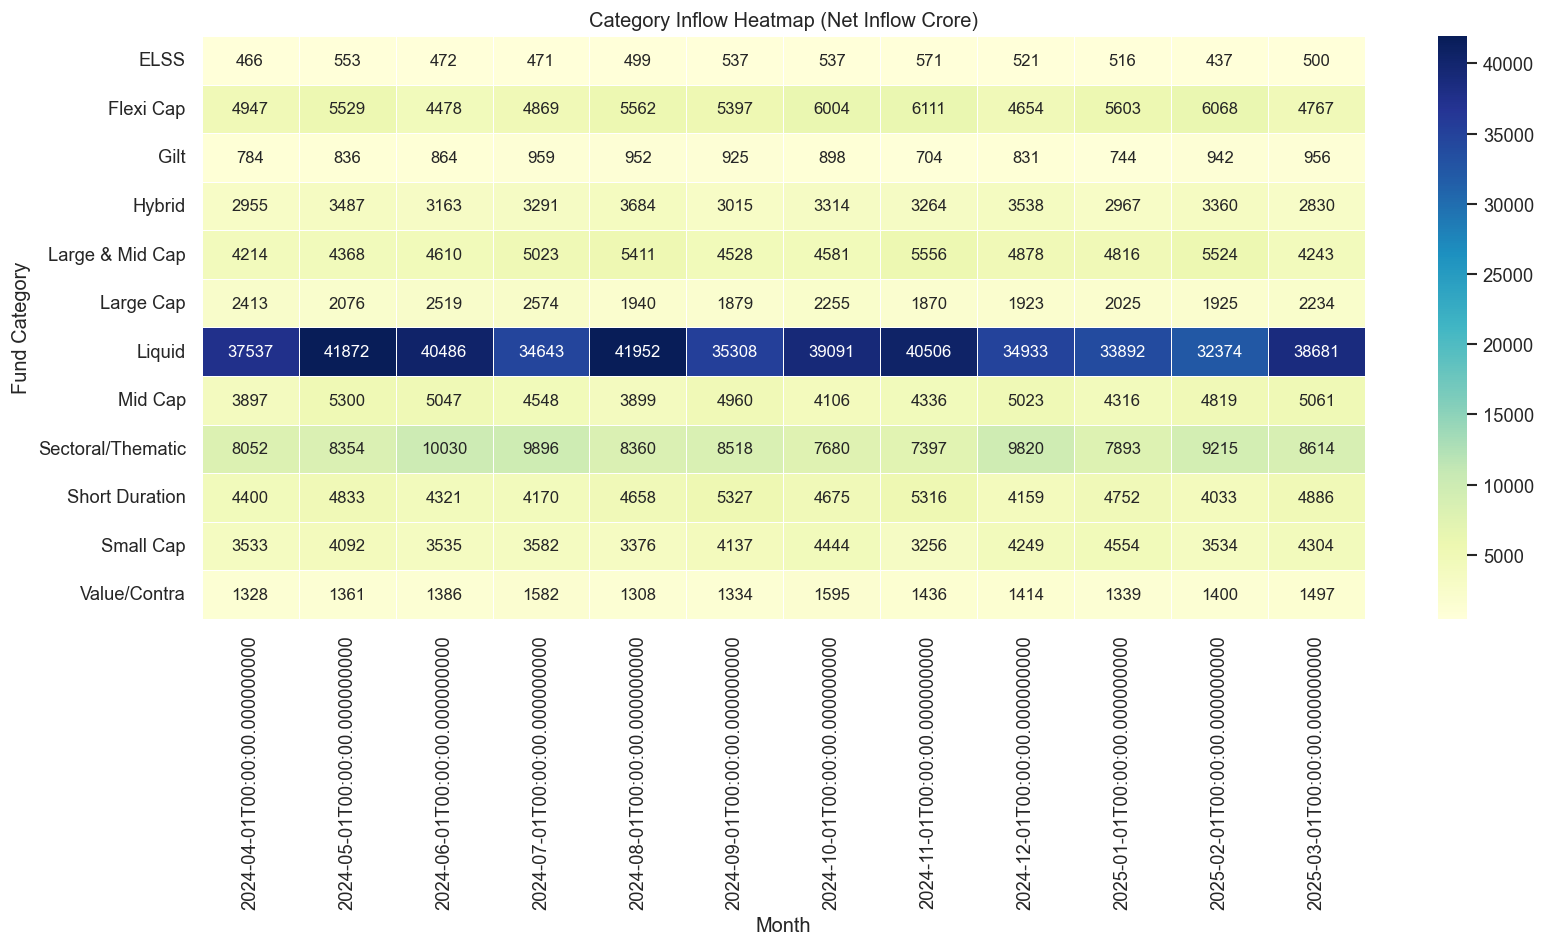

In [5]:
cat_pivot = category_inflows.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum').fillna(0)
plt.figure(figsize=(14, 8))
sns.heatmap(cat_pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Category Inflow Heatmap (Net Inflow Crore)')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'category_inflow_heatmap.png')
plt.show()

## 5. Investor Demographics

Age distribution, SIP amount by age group, and gender split for investor SIP transactions.

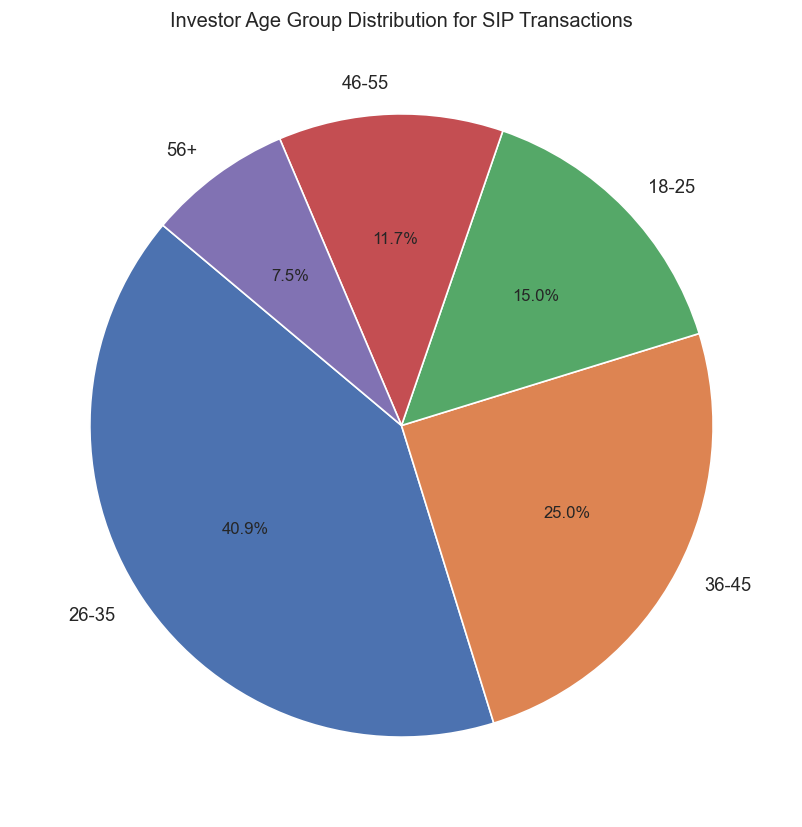

C:\Users\rajve\AppData\Local\Temp\ipykernel_30624\1825796205.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', palette='pastel')


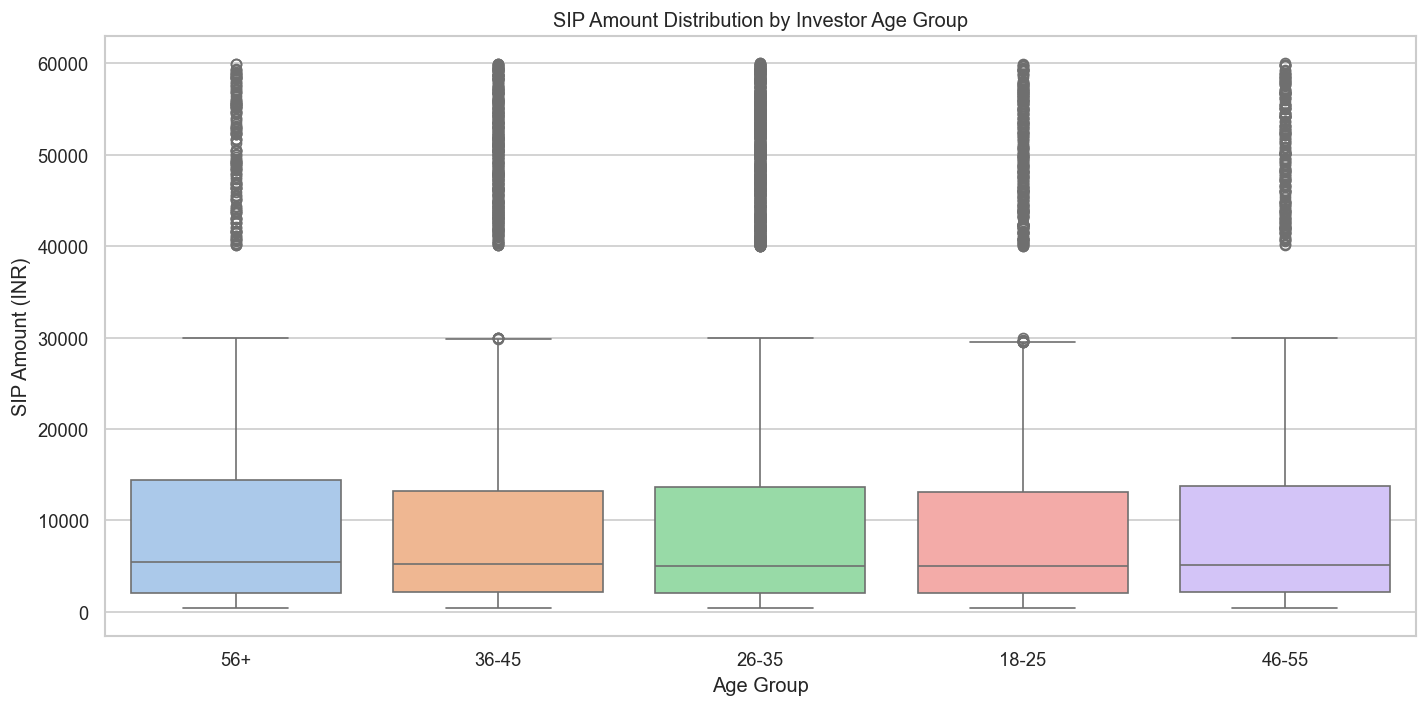

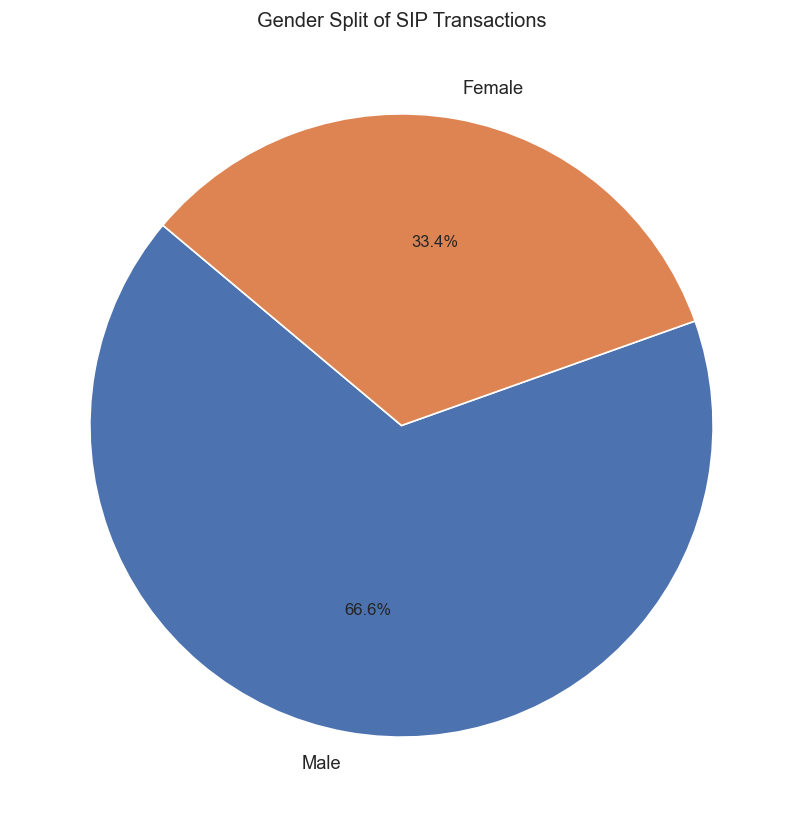

In [6]:
sip_tx = transactions.query("transaction_type == 'SIP'")
age_counts = sip_tx['age_group'].value_counts()
age_labels = age_counts.index.astype(str).tolist()
plt.figure(figsize=(7, 7))
plt.pie(age_counts, labels=age_labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white'})
plt.title('Investor Age Group Distribution for SIP Transactions')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'investor_age_distribution.png')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', palette='pastel')
plt.title('SIP Amount Distribution by Investor Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (INR)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sip_amount_by_age_group.png')
plt.show()

plt.figure(figsize=(7, 7))
gender_counts = sip_tx['gender'].value_counts()
gender_labels = gender_counts.index.astype(str).tolist()
plt.pie(gender_counts, labels=gender_labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white'})
plt.title('Gender Split of SIP Transactions')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gender_split_sip.png')
plt.show()

## 6. Geographic Distribution

SIP amount by state and city-tier share for T30 vs B30.

C:\Users\rajve\AppData\Local\Temp\ipykernel_30624\3062782896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sip.head(15), y='state', x='amount_inr', palette='coolwarm')


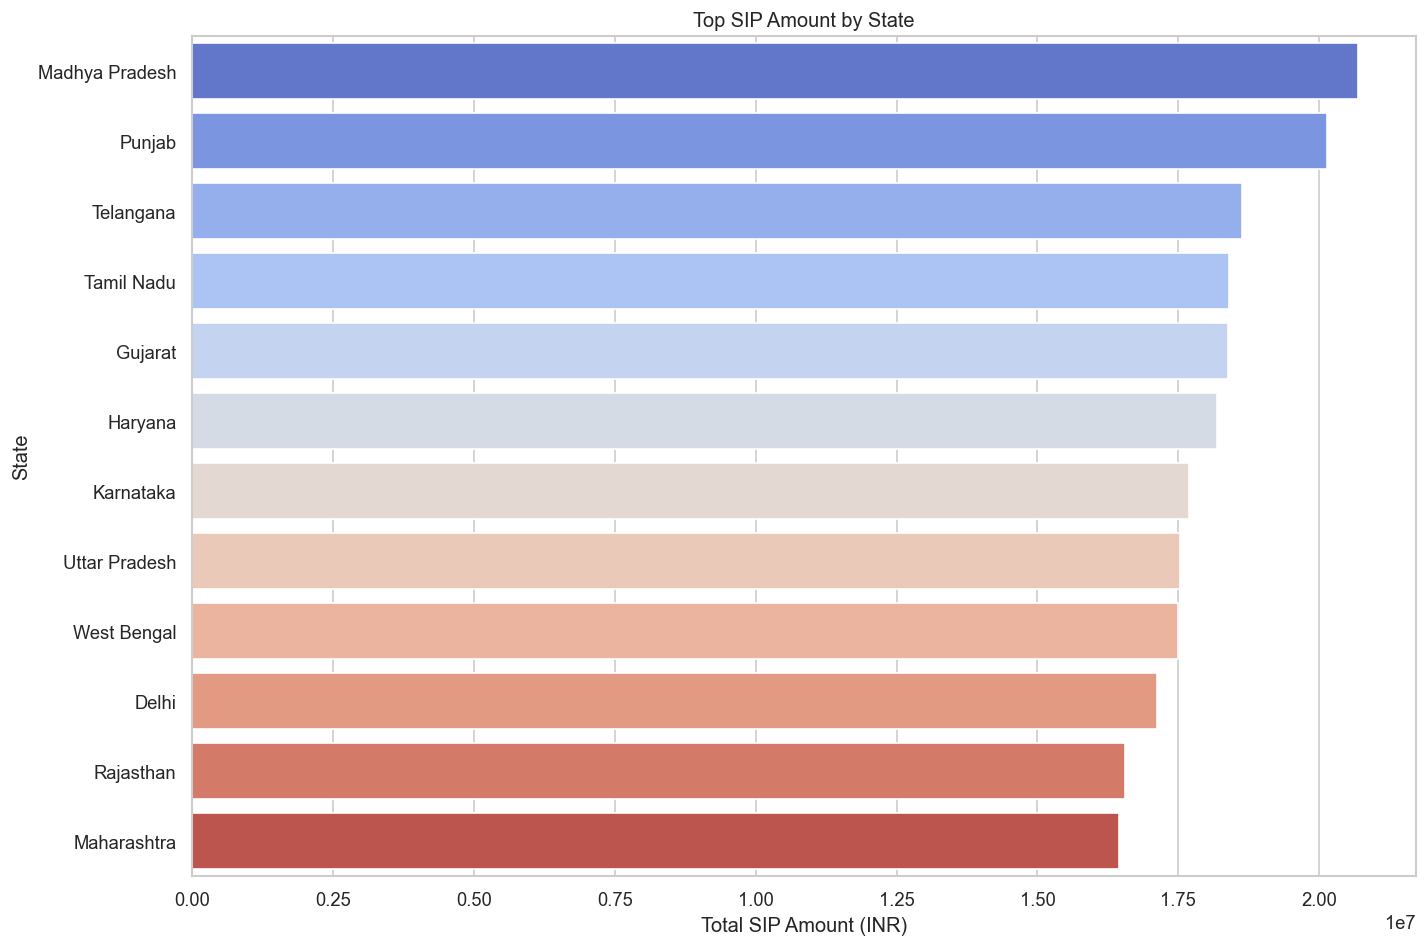

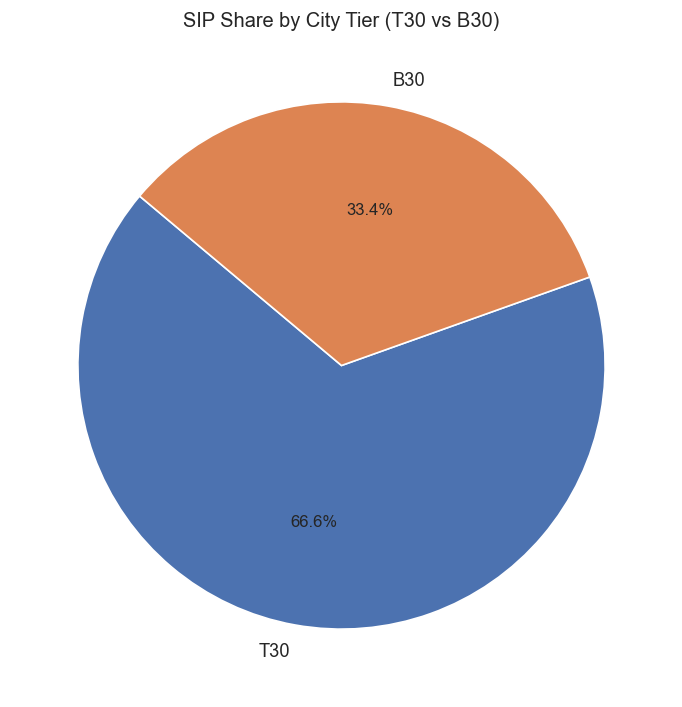

In [7]:
state_sip = (
    sip_tx.groupby('state', as_index=False)
    .agg(amount_inr=('amount_inr', 'sum'))
    .sort_values(by='amount_inr', ascending=False)
)
plt.figure(figsize=(12, 8))
sns.barplot(data=state_sip.head(15), y='state', x='amount_inr', palette='coolwarm')
plt.title('Top SIP Amount by State')
plt.xlabel('Total SIP Amount (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sip_amount_by_state.png')
plt.show()

plt.figure(figsize=(6, 6))
city_tier = sip_tx['city_tier'].value_counts()
city_tier_labels = city_tier.index.astype(str).tolist()
plt.pie(city_tier, labels=city_tier_labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white'})
plt.title('SIP Share by City Tier (T30 vs B30)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'city_tier_pie.png')
plt.show()

## 7. Folio Count Growth & Milestones

Line chart from 13.26 Cr folios in Jan 2022 to 26.12 Cr in Dec 2025, with milestone annotations.

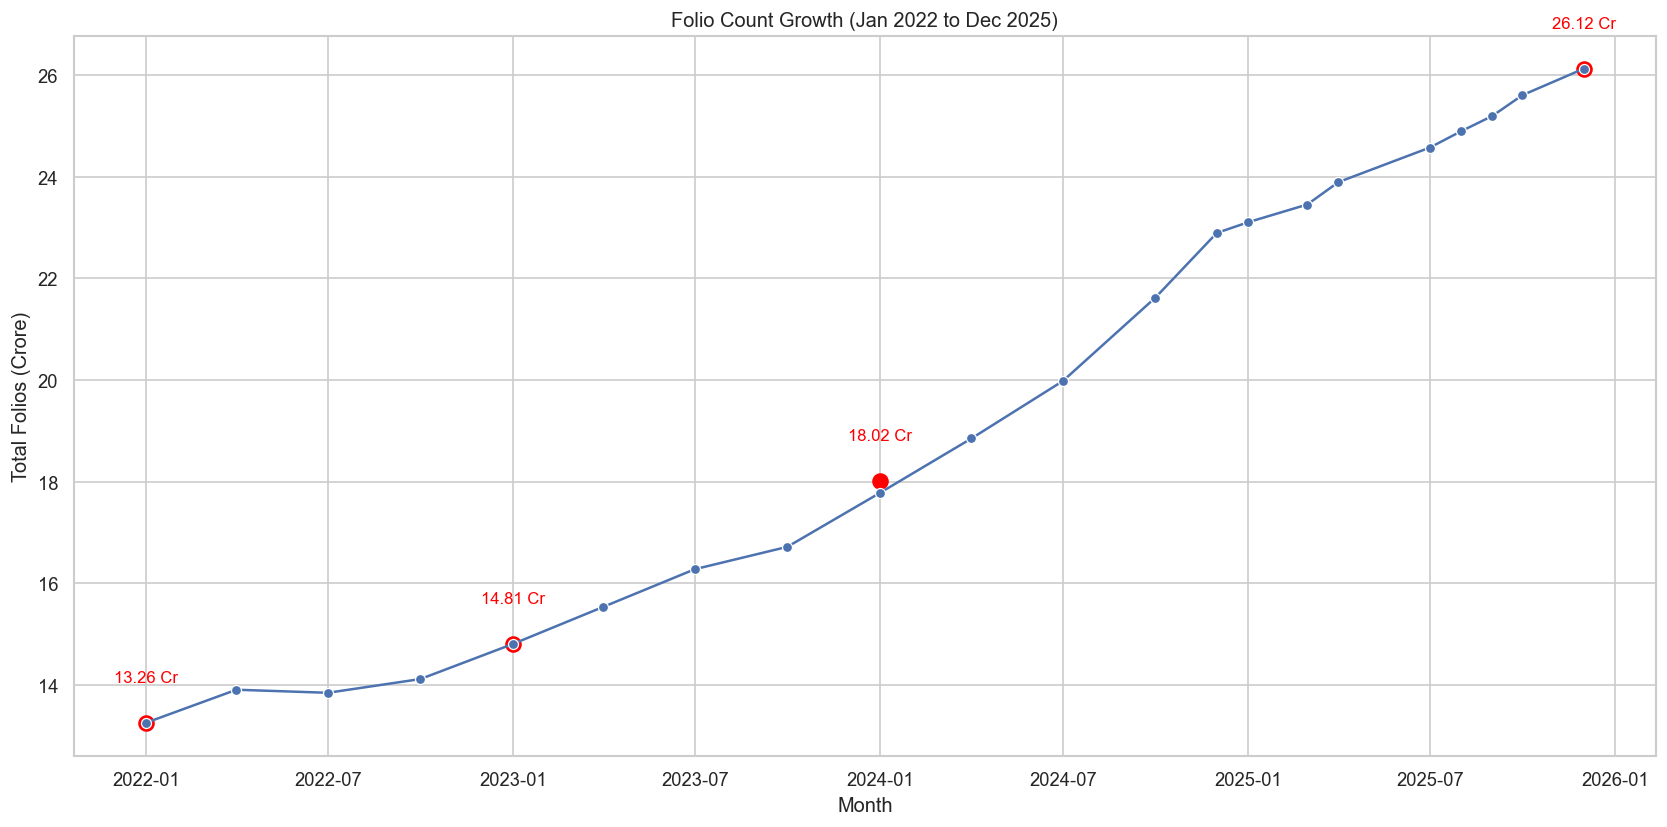

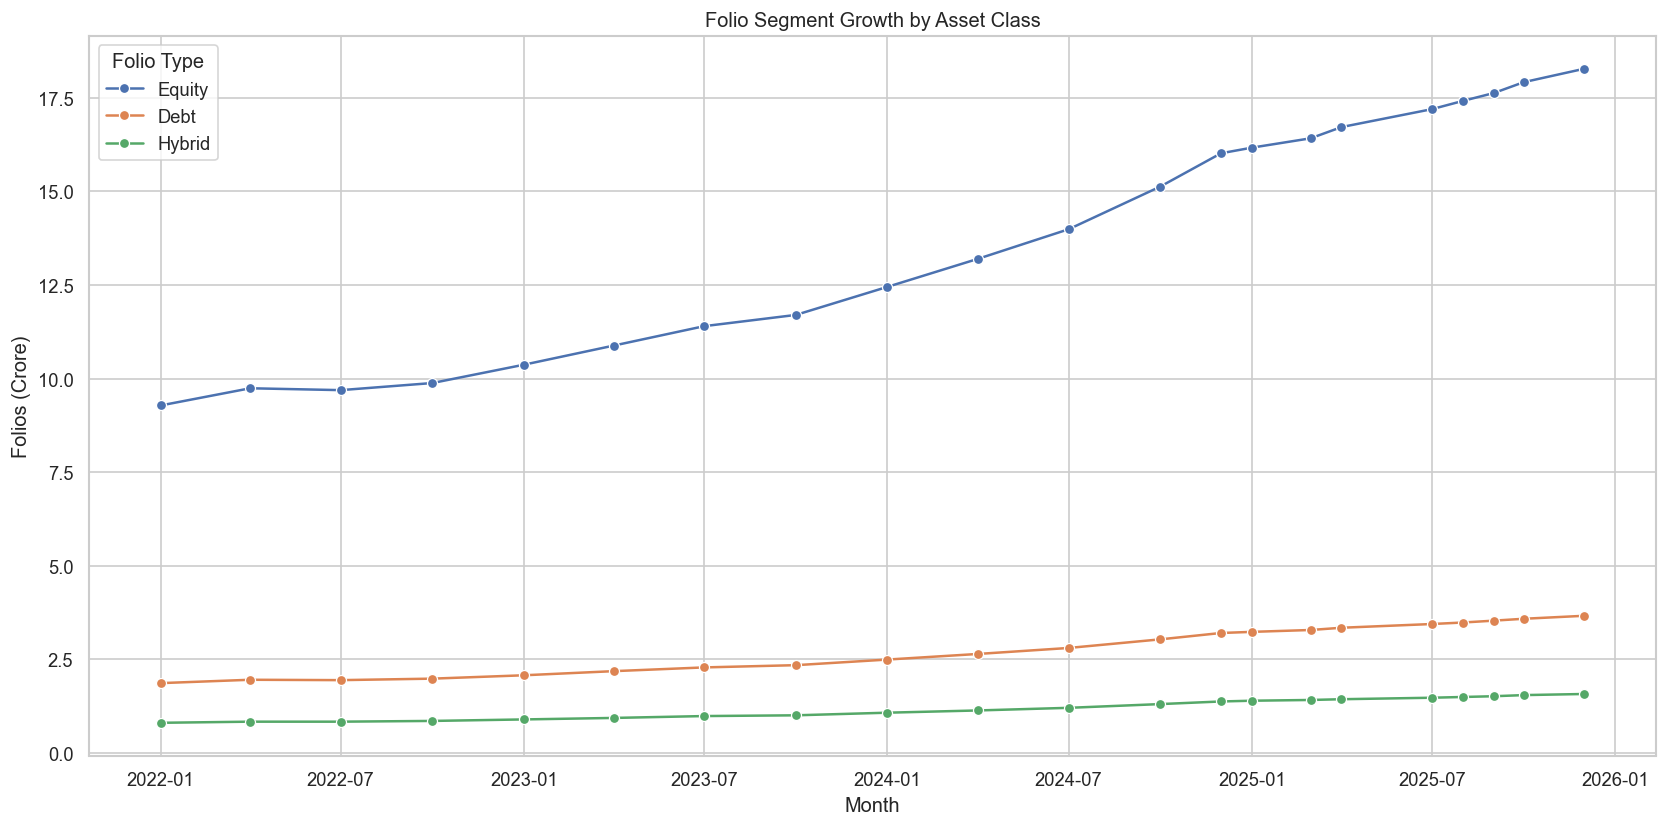

In [8]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=folio_count.sort_values('month'), x='month', y='total_folios_crore', marker='o')
plt.title('Folio Count Growth (Jan 2022 to Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
for date_str, value in [('2022-01-01', 13.26), ('2023-01-01', 14.81), ('2024-01-01', 18.02), ('2025-12-01', 26.12)]:
    date_value = pd.to_datetime(date_str)
    plt.scatter(date_value, value, s=80, color='red') # pyright: ignore[reportArgumentType]
    plt.text(date_value, value + 0.8, f'{value} Cr', ha='center', color='red') # type: ignore
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'folio_count_growth.png')
plt.show()

plt.figure(figsize=(14, 7))
folio_long = folio_count.melt(id_vars=['month'], value_vars=['equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore'], var_name='folio_type', value_name='crore')
folio_long['folio_type'] = folio_long['folio_type'].str.replace('_folios_crore', '').str.title()
sns.lineplot(data=folio_long, x='month', y='crore', hue='folio_type', marker='o')
plt.title('Folio Segment Growth by Asset Class')
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')
plt.legend(title='Folio Type')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'folio_composition_by_category.png')
plt.show()

## 8. NAV Return Correlation Matrix — Seaborn

Pairwise correlation of daily returns for 10 selected funds, shown as a heatmap.

C:\Users\rajve\AppData\Local\Temp\ipykernel_30624\4251724383.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(daily_return=x['nav'].pct_change()))


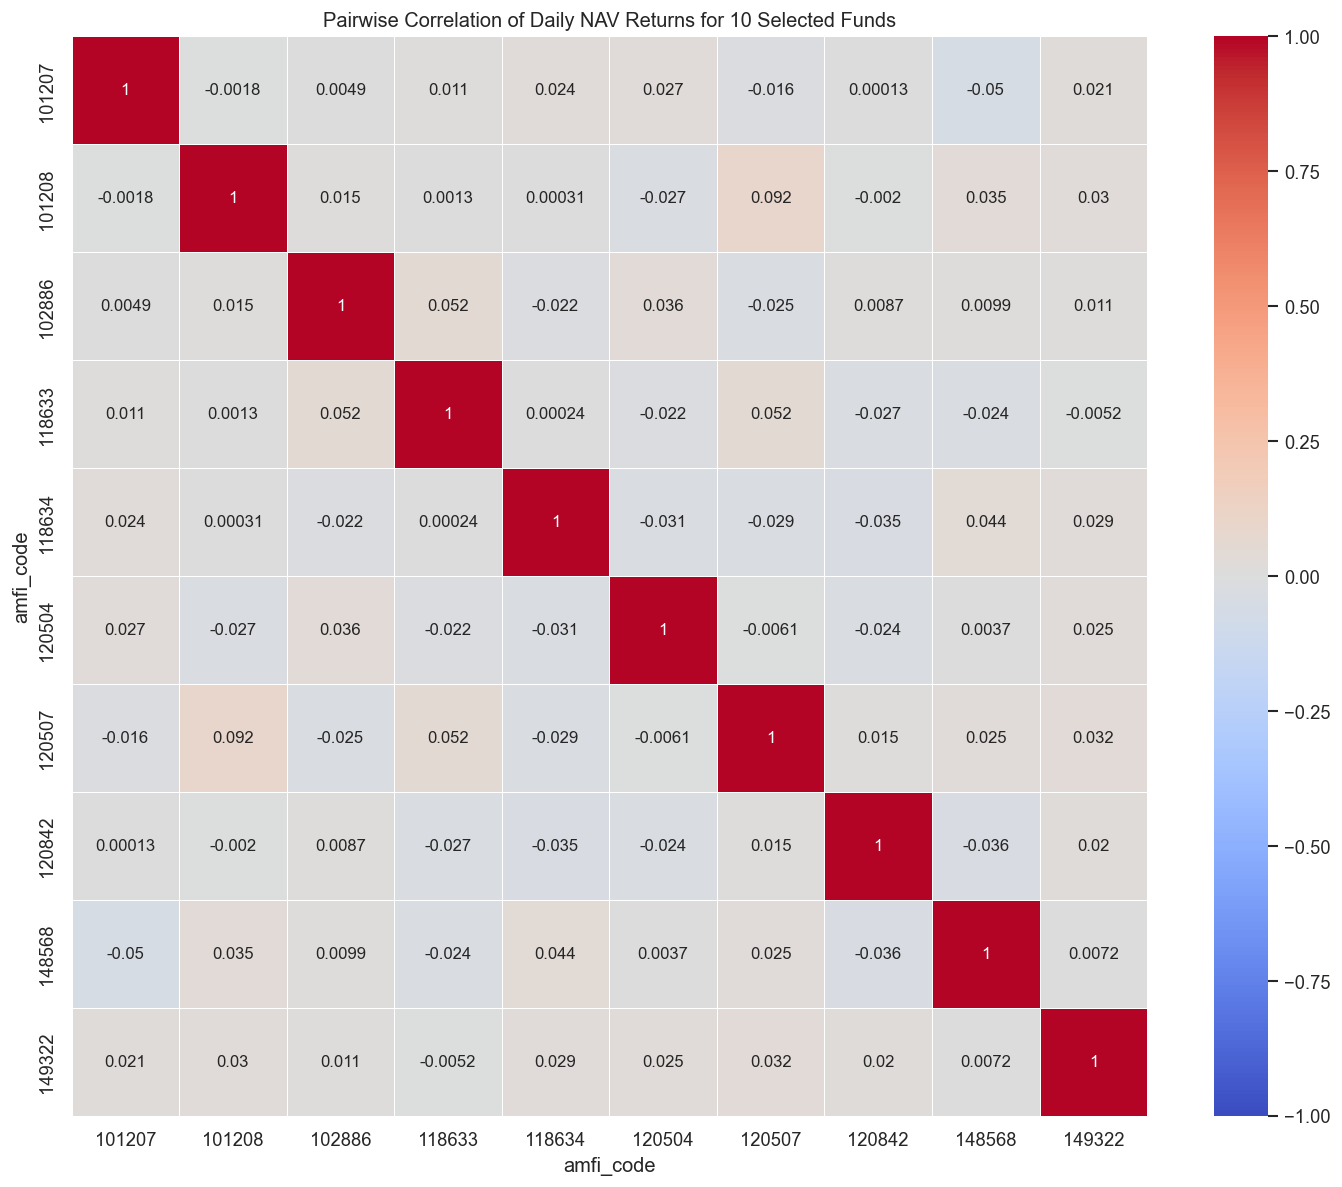

In [9]:
selected_amfi = scheme_perf.sort_values('aum_crore', ascending=False).head(10)['amfi_code'].tolist()
returns = (
    nav_history[nav_history['amfi_code'].isin(selected_amfi)]
    .sort_values(['amfi_code', 'date'])
    .groupby('amfi_code')
    .apply(lambda x: x.assign(daily_return=x['nav'].pct_change()))
    .reset_index(drop=True)
)
returns_pivot = returns.pivot(index='date', columns='amfi_code', values='daily_return').dropna()
corr_matrix = returns_pivot.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Pairwise Correlation of Daily NAV Returns for 10 Selected Funds')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'nav_return_correlation_matrix.png')
plt.show()

## 9. Sector Allocation Donut

Aggregate sector weights across all equity portfolios displayed as a donut chart.

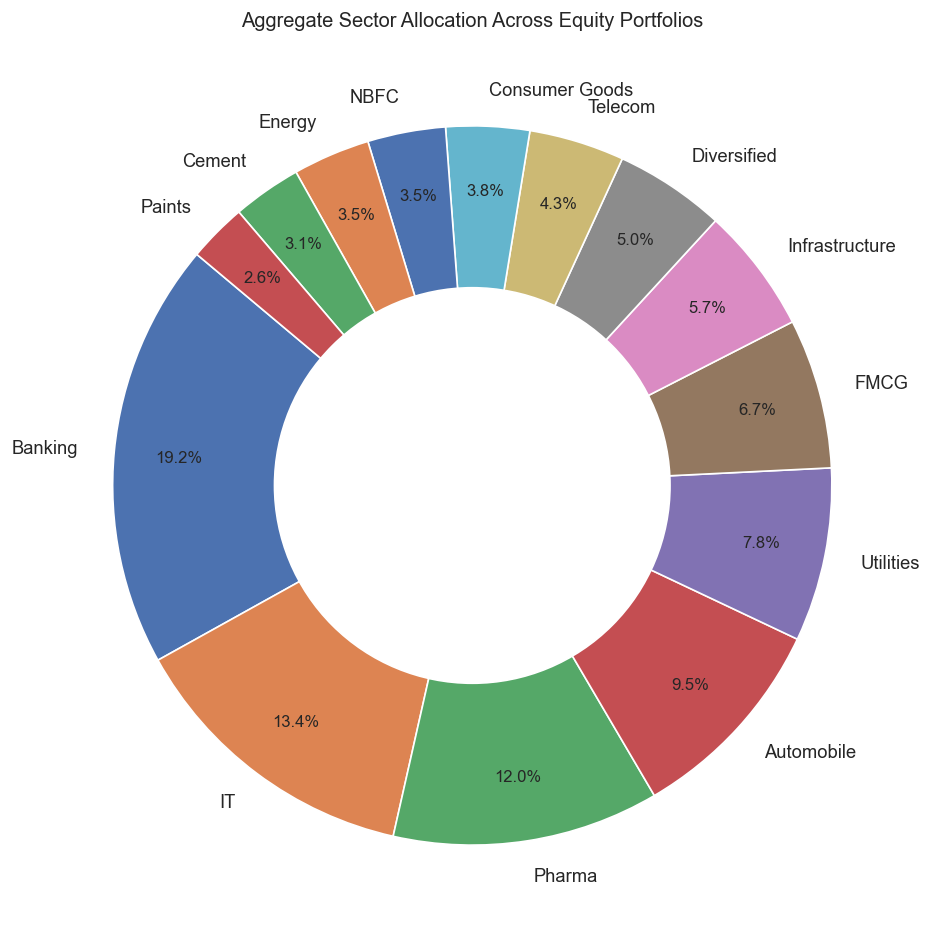

In [10]:
sector_alloc = (
    portfolio_holdings.groupby('sector', as_index=False)
    .agg(weight_pct=('weight_pct', 'sum'))
    .sort_values(by='weight_pct', ascending=False)
)
plt.figure(figsize=(8, 8))
sector_labels = sector_alloc['sector'].astype(str).tolist()
plt.pie(sector_alloc['weight_pct'], labels=sector_labels, autopct='%1.1f%%', startangle=140, pctdistance=0.82)
centre_circle = Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)
plt.title('Aggregate Sector Allocation Across Equity Portfolios')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sector_allocation_donut.png')
plt.show()

## 10. Key EDA Insights

1. 2023 showed a clear bull-run window for most schemes, while 2024 saw a broad correction phase that impacted daily NAV momentum.
2. SBI Mutual Fund remains the dominant fund house with the largest annual AUM across 2022-2025.
3. Monthly SIP inflows peaked at ₹31,002 Cr in Dec 2025, underscoring continuing retail participation.
4. Large Cap and Flexi Cap categories are among the strongest net inflow performers over the sample months.
5. SIP investors are concentrated in the 26-35 and 36-45 age bands.
6. SIP amount distributions are wider for older age groups, indicating higher ticket sizes for mature investors.
7. Gender split is roughly balanced but shows notable female participation in SIP flows.
8. State-level SIP concentrations appear strongest in top states, highlighting regional adoption patterns.
9. Total folios grew from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, capturing sustained market penetration.
10. Daily NAV return correlations for the top 10 funds show both highly correlated pairs and differentiated risk-return behavior.